# PPy-in-muscle Instron tensile tests (2026-06-22) - Young's modulus

Uniaxial pull tests (ramp to ~10 mm, ~0.2 mm/s). The Instron CSVs export
`Time (s), Displacement (mm), Force (kN)` after a short header, and the **sample dimensions are encoded
in each filename** (`..._W mm_wide_L mm_long_T mm_thick.csv`).

With dimensions we now compute real mechanics:
- **stress** $\sigma = F / (W\,T)$ (MPa), **strain** $\varepsilon = \Delta\ell / L$ (gauge length = the
  `long` dimension); displacement is zeroed to the first sample, and **force is zeroed to each test's
  minimum** so a pre-strained start (e.g. DAY1-4, which dips to -0.8 N) doesn't go negative;
- **Young's modulus** $E$ = slope of $\sigma$ vs $\varepsilon$ over the linear elastic region (the 25-75%
  of-peak-stress band on the pre-peak rising flank, which skips the toe and the post-peak roll-off).

Samples are grouped by **formalin-fixation day** (1-4); files tagged **`actuated`** were electrochemically
cycled and are drawn as **stars** (others as dots). Raw force-displacement curves are kept first for
reference, then stress-strain, then the modulus summary.

In [1]:
import os, re, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

DIR = '/Users/yitong/Documents/GitHub/chicken_necrobots/6.22.26_ppy_muslce_instron_experiments'

def load(path):
    """Parse an Instron CSV (skip header), coerce numerics, drop junk rows, and ZERO disp & force
    to the first reading."""
    raw = open(path).read().splitlines()
    hi = [i for i, l in enumerate(raw) if 'Time' in l and 'Force' in l][0]   # column-name row
    d = pd.read_csv(path, skiprows=hi + 2, header=None, usecols=[1, 2, 3],
                    names=['t_s', 'disp_mm', 'force_kN'])
    for c in d.columns:
        d[c] = pd.to_numeric(d[c], errors='coerce')
    d = d.dropna().reset_index(drop=True)
    d['force_N'] = d['force_kN'] * 1000.0
    d['disp0_mm'] = d['disp_mm'] - d['disp_mm'].iloc[0]    # zero displacement to start
    d['force0_N'] = d['force_N'] - d['force_N'].min()      # zero force to its MINIMUM (handles a
    return d                                               # pre-strained start, e.g. DAY1-4, dipping below 0)

def meta(fname):
    base = os.path.basename(fname)
    day = int(re.search(r'day[-_ ]?(\d)', base, re.I).group(1))
    actuated = 'actuat' in base.lower()
    label = base.split('_')[0]                             # e.g. 'DAY1-2' / 'DAY1-4-actuated'
    W = float(re.search(r'([\d.]+)mm_wide', base).group(1))
    L = float(re.search(r'([\d.]+)(?:mm)?_long', base).group(1))   # one file omits 'mm' before _long
    T = float(re.search(r'([\d.]+)mm_thick', base).group(1))
    return dict(day=day, actuated=actuated, label=label, file=base,
                W_mm=W, L_mm=L, T_mm=T, area_mm2=W*T)

def youngs_modulus(stress, strain):
    """E (MPa) = slope of stress vs strain over the linear elastic band: pre-peak rising flank only,
    25-75% of peak stress (skips the toe region and the post-peak roll-off)."""
    ipk = int(np.argmax(stress)); s = stress[:ipk+1]; e = strain[:ipk+1]
    if len(s) < 5:
        return np.nan
    pk = s.max(); band = (s >= 0.25*pk) & (s <= 0.75*pk)
    if band.sum() < 5:
        return np.nan
    return float(np.polyfit(e[band], s[band], 1)[0])

FILES = sorted(glob.glob(os.path.join(DIR, '*.csv')))
samples = []
for f in FILES:
    m = meta(f); d = load(f)
    d['stress_MPa'] = d['force0_N'] / m['area_mm2']        # N/mm^2 = MPa
    d['strain'] = d['disp0_mm'] / m['L_mm']                # dimensionless
    d['strain_pct'] = d['strain'] * 100.0
    m['E_MPa'] = youngs_modulus(d['stress_MPa'].values, d['strain'].values)
    m['peak_stress_MPa'] = float(d['stress_MPa'].max())
    m['data'] = d; samples.append(m)
samples.sort(key=lambda s: (s['day'], s['actuated'], s['label']))
print(f'Loaded {len(samples)} tests:')
for s in samples:
    print(f"  day {s['day']}  {'ACT ' if s['actuated'] else '    '}{s['label']:20} "
          f"A={s['area_mm2']:.2f}mm2 L0={s['L_mm']:.2f}mm  peak sigma={s['peak_stress_MPa']:.3f}MPa  E={s['E_MPa']:.3f}MPa")

# Outliers: excluded from averages and greyed in plots (DAY1-2 ~27 MPa, ~4x the next stiffest).
OUTLIER_LABELS = ['DAY1-2']
for s in samples:
    s['is_outlier'] = s['label'] in OUTLIER_LABELS
print('\nFlagged outliers (greyed, excluded from averages):', OUTLIER_LABELS)
DAY_COLOR = {1: '#9467bd', 2: '#1f77b4', 3: '#d62728', 4: '#2ca02c'}
OUT_COLOR = '#bdbdbd'   # grey for outliers

Loaded 10 tests:
  day 1      DAY1-2               A=2.76mm2 L0=8.44mm  peak sigma=3.043MPa  E=27.330MPa
  day 1      DAY1-3               A=5.37mm2 L0=6.00mm  peak sigma=0.298MPa  E=0.420MPa
  day 1  ACT DAY1-4-actuated      A=3.49mm2 L0=8.56mm  peak sigma=0.830MPa  E=7.006MPa
  day 2      DAY2-1               A=4.47mm2 L0=6.10mm  peak sigma=0.403MPa  E=0.117MPa
  day 2      DAY2-2               A=3.44mm2 L0=7.44mm  peak sigma=0.436MPa  E=1.062MPa
  day 3      DAY3-1               A=2.03mm2 L0=4.60mm  peak sigma=0.443MPa  E=0.707MPa
  day 3      DAY3-2               A=3.00mm2 L0=3.54mm  peak sigma=1.200MPa  E=3.746MPa
  day 3  ACT DAY3-3-actuated      A=2.31mm2 L0=5.90mm  peak sigma=1.169MPa  E=7.057MPa
  day 4      DAY4-1               A=4.35mm2 L0=4.90mm  peak sigma=1.241MPa  E=1.187MPa
  day 4  ACT DAY4-2-actuated      A=2.04mm2 L0=11.58mm  peak sigma=0.590MPa  E=6.043MPa

Flagged outliers (greyed, excluded from averages): ['DAY1-2']


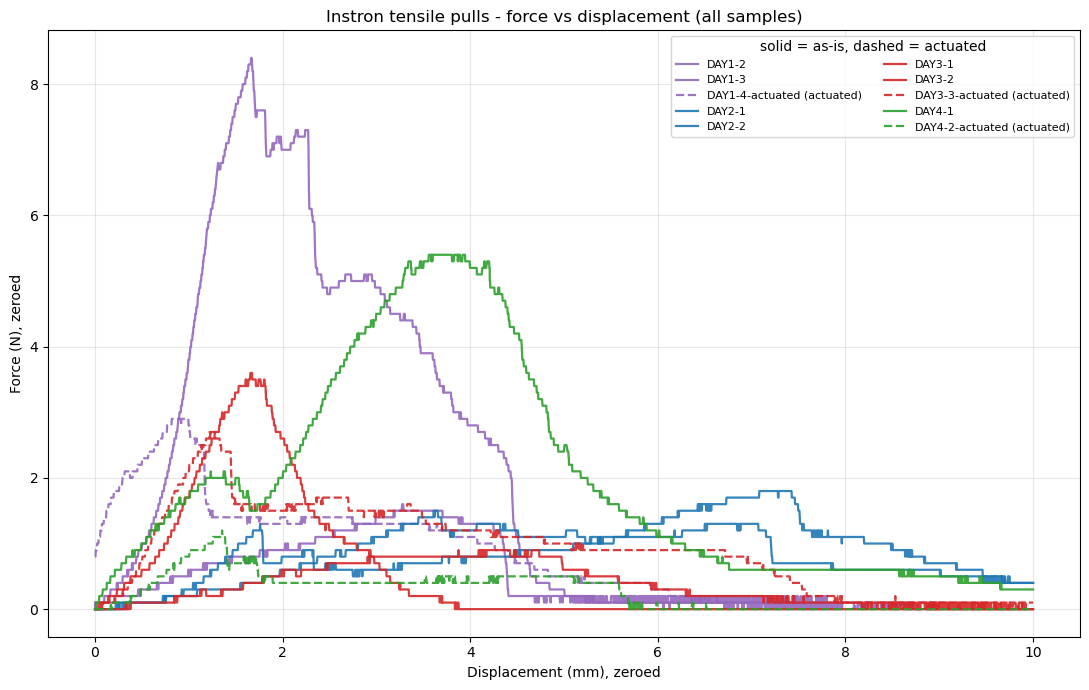

In [2]:
# All tests overlaid: zeroed Force vs Displacement. Color = fixation day; dashed = actuated.
fig, ax = plt.subplots(figsize=(11, 7))
for s in samples:
    d = s['data']
    ax.plot(d['disp0_mm'], d['force0_N'], color=DAY_COLOR[s['day']],
            ls='--' if s['actuated'] else '-', lw=1.6, alpha=0.9,
            label=f"{s['label']}{' (actuated)' if s['actuated'] else ''}")
ax.set_xlabel('Displacement (mm), zeroed'); ax.set_ylabel('Force (N), zeroed')
ax.set_title('Instron tensile pulls - force vs displacement (all samples)')
ax.grid(True, alpha=0.3)
# legend grouped, with a day-color note
ax.legend(fontsize=8, ncol=2, title='solid = as-is, dashed = actuated')
fig.tight_layout(); plt.show()

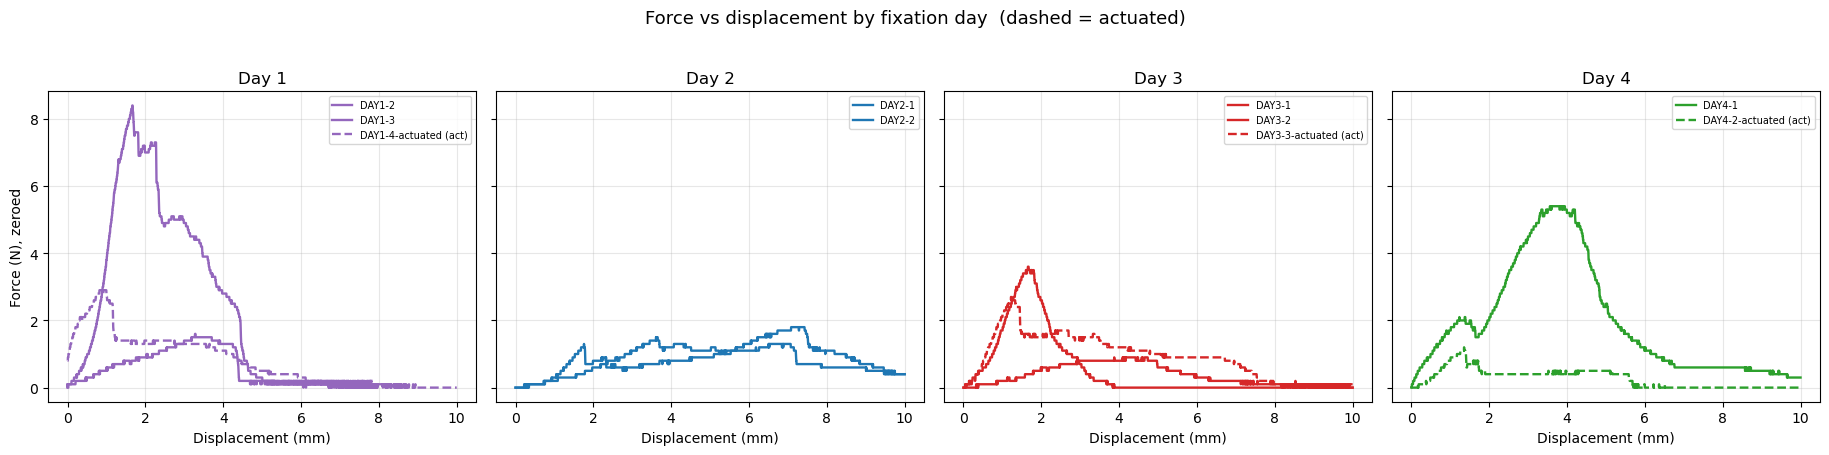

In [3]:
# Per-day small multiples (clearer than the full overlay). Shared axes for easy comparison.
days = sorted({s['day'] for s in samples})
fig, axes = plt.subplots(1, len(days), figsize=(4.6*len(days), 4.6), sharex=True, sharey=True)
for ax, day in zip(np.atleast_1d(axes), days):
    for s in [s for s in samples if s['day'] == day]:
        d = s['data']
        ax.plot(d['disp0_mm'], d['force0_N'], color=DAY_COLOR[day],
                ls='--' if s['actuated'] else '-', lw=1.7,
                label=f"{s['label']}{' (act)' if s['actuated'] else ''}")
    ax.set_title(f'Day {day}'); ax.set_xlabel('Displacement (mm)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
np.atleast_1d(axes)[0].set_ylabel('Force (N), zeroed')
fig.suptitle('Force vs displacement by fixation day  (dashed = actuated)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

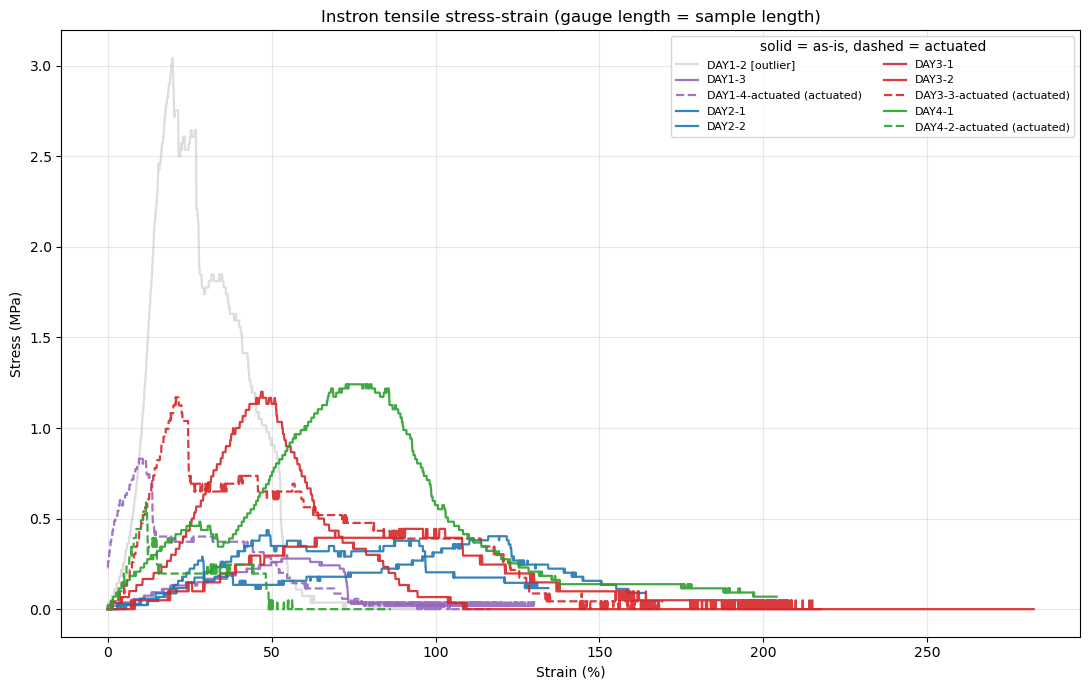

In [4]:
# Stress-strain curves (now that we have dimensions). Color = day; actuated dashed. The dot on each
# curve marks the upper end of the elastic band used for the modulus fit.
fig, ax = plt.subplots(figsize=(11, 7))
for s in samples:
    d = s['data']
    col = OUT_COLOR if s['is_outlier'] else DAY_COLOR[s['day']]
    ax.plot(d['strain_pct'], d['stress_MPa'], color=col,
            ls='--' if s['actuated'] else '-', lw=1.6, alpha=0.5 if s['is_outlier'] else 0.9,
            label=f"{s['label']}{' (actuated)' if s['actuated'] else ''}{' [outlier]' if s['is_outlier'] else ''}")
ax.set_xlabel('Strain (%)'); ax.set_ylabel('Stress (MPa)')
ax.set_title('Instron tensile stress-strain (gauge length = sample length)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8, ncol=2, title='solid = as-is, dashed = actuated')
fig.tight_layout(); plt.show()

Young's modulus per sample (is_outlier excluded from averages):


,label,day,actuated,is_outlier,W_mm,L_mm,T_mm,area_mm2,peak_stress_MPa,E_MPa
0,DAY1-2,1,False,True,2.76,8.44,1.00,2.760,3.043,27.330
1,DAY1-3,1,False,False,3.40,6.00,1.58,5.372,0.298,0.420
2,DAY1-4-actuated,1,True,False,3.88,8.56,0.90,3.492,0.830,7.006
3,DAY2-1,2,False,False,3.44,6.10,1.30,4.472,0.403,0.117
4,DAY2-2,2,False,False,3.44,7.44,1.00,3.440,0.436,1.062
5,DAY3-1,3,False,False,2.90,4.60,0.70,2.030,0.443,0.707
6,DAY3-2,3,False,False,2.50,3.54,1.20,3.000,1.200,3.746
7,DAY3-3-actuated,3,True,False,3.30,5.90,0.70,2.310,1.169,7.057
8,DAY4-1,4,False,False,2.90,4.90,1.50,4.350,1.241,1.187
9,DAY4-2-actuated,4,True,False,3.70,11.58,0.55,2.035,0.590,6.043


\nDay-by-day modulus (MPa):
  day | mean incl. outlier | mean excl. outlier | median (robust)
   1  |      11.59        |       3.71         |     7.01
   2  |       0.59        |       0.59         |     0.59
   3  |       3.84        |       3.84         |     3.75
   4  |       3.62        |       3.62         |     3.62


/var/folders/1j/7hbmv0v92x141ltlqxmr9dzw0000gn/T/ipykernel_8977/3004876042.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


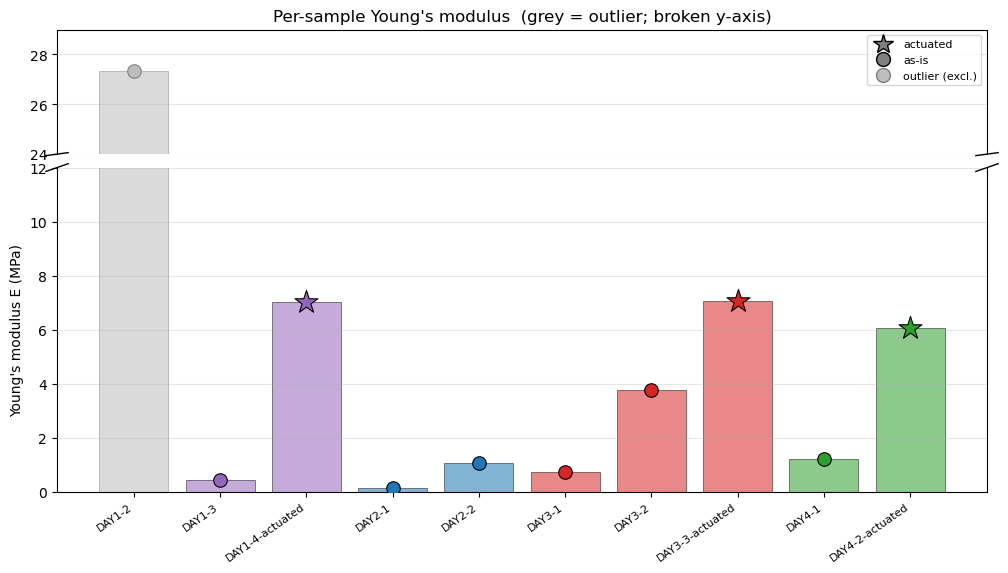

/var/folders/1j/7hbmv0v92x141ltlqxmr9dzw0000gn/T/ipykernel_8977/3004876042.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()


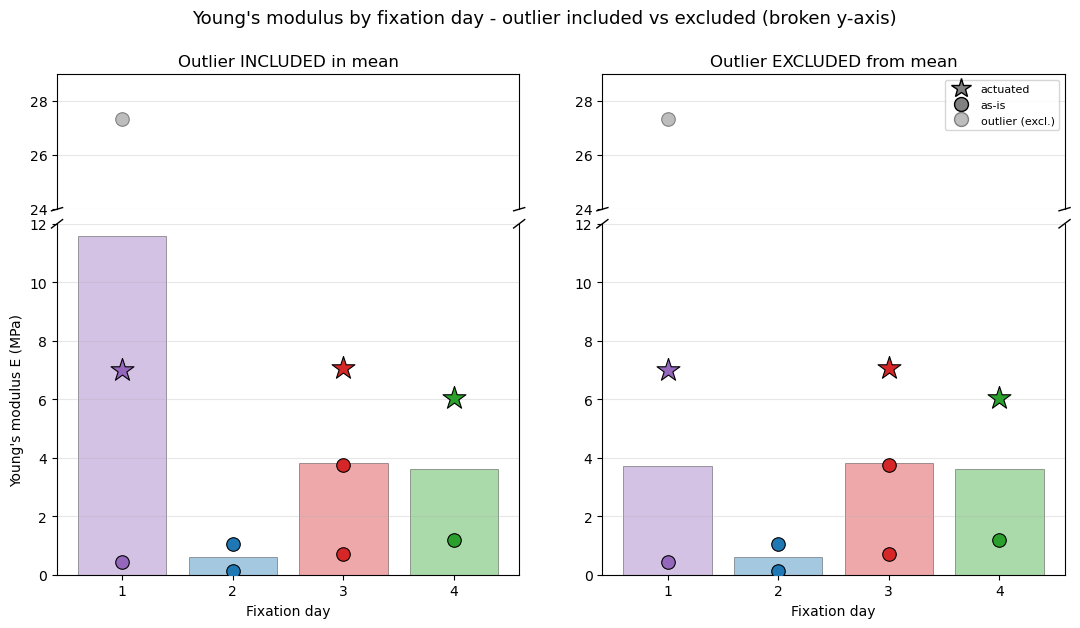

\nActuated vs as-is, outlier excluded (mean E):
  as-is   : n=6  mean E = 1.21 MPa  (range 0.12-3.75)
  actuated: n=3  mean E = 6.70 MPa  (range 6.04-7.06)


In [5]:
# Young's modulus summary. Star = actuated, dot = as-is; the DAY1-2 outlier is greyed and left out of
# the averages. Broken y-axis (gap from ~12 to ~24 MPa) so the near-0 cluster is readable.
from matplotlib.lines import Line2D
mod = pd.DataFrame([dict(label=s['label'], day=s['day'], actuated=s['actuated'], is_outlier=s['is_outlier'],
                         W_mm=s['W_mm'], L_mm=s['L_mm'], T_mm=s['T_mm'], area_mm2=round(s['area_mm2'], 3),
                         peak_stress_MPa=round(s['peak_stress_MPa'], 3), E_MPa=round(s['E_MPa'], 3))
                    for s in samples]).sort_values(['day', 'actuated', 'label']).reset_index(drop=True)
print("Young's modulus per sample (is_outlier excluded from averages):")
display(mod)

days = sorted(mod['day'].unique())
core = mod[~mod['is_outlier']]
print('\\nDay-by-day modulus (MPa):')
print('  day | mean incl. outlier | mean excl. outlier | median (robust)')
for dd in days:
    a = mod[mod['day'] == dd]['E_MPa']; e = core[core['day'] == dd]['E_MPa']
    print(f'   {dd}  |     {a.mean():6.2f}        |     {e.mean():6.2f}         |   {a.median():6.2f}')

YLO_TOP, YHI_TOP = 24, 29          # broken segment for the outlier
YBOT = 12                          # bottom segment 0..YBOT (holds all means + non-outlier points)
def style(r):
    return dict(marker='*' if r['actuated'] else 'o', s=300 if r['actuated'] else 95,
                color=OUT_COLOR if r['is_outlier'] else DAY_COLOR[r['day']],
                ec='gray' if r['is_outlier'] else 'k', lw=0.8, zorder=5)
def add_break(at, ab):
    at.spines['bottom'].set_visible(False); ab.spines['top'].set_visible(False)
    at.tick_params(bottom=False, labelbottom=False)
    at.set_ylim(YLO_TOP, YHI_TOP); ab.set_ylim(0, YBOT)
    dd = .012
    kw = dict(transform=at.transAxes, color='k', clip_on=False, lw=1)
    at.plot((-dd, dd), (-dd, dd), **kw); at.plot((1-dd, 1+dd), (-dd, dd), **kw)
    kw.update(transform=ab.transAxes)
    ab.plot((-dd, dd), (1-dd, 1+dd), **kw); ab.plot((1-dd, 1+dd), (1-dd, 1+dd), **kw)
LEG = [Line2D([0],[0],marker='*',color='w',markerfacecolor='gray',markeredgecolor='k',markersize=15,label='actuated'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='gray',markeredgecolor='k',markersize=10,label='as-is'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor=OUT_COLOR,markeredgecolor='gray',markersize=10,label='outlier (excl.)')]

# ===== Figure 1: per-sample modulus, broken y-axis, outlier greyed =====
xs = np.arange(len(mod))
fig, (at, ab) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                             gridspec_kw={'height_ratios': [1, 2.6], 'hspace': 0.06})
for ax in (at, ab):
    ax.bar(xs, mod['E_MPa'], color=[OUT_COLOR if o else DAY_COLOR[d] for o, d in zip(mod['is_outlier'], mod['day'])],
           alpha=0.55, ec=['gray' if o else 'k' for o in mod['is_outlier']], lw=0.6)
    for x, (_, r) in zip(xs, mod.iterrows()):
        ax.scatter(x, r['E_MPa'], **style(r))
    ax.grid(True, axis='y', alpha=0.3)
add_break(at, ab)
ab.set_xticks(xs); ab.set_xticklabels(mod['label'], rotation=35, ha='right', fontsize=8)
ab.set_ylabel("Young's modulus E (MPa)"); at.legend(handles=LEG, fontsize=8, loc='upper right')
at.set_title("Per-sample Young's modulus  (grey = outlier; broken y-axis)")
fig.tight_layout(); plt.show()

# ===== Figure 2: per-day mean, INCLUDED vs EXCLUDED, broken y-axis =====
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), sharex='col',
                         gridspec_kw={'height_ratios': [1, 2.6], 'hspace': 0.06, 'wspace': 0.18})
for col, (excl, title) in enumerate([(False, 'Outlier INCLUDED in mean'), (True, 'Outlier EXCLUDED from mean')]):
    src = core if excl else mod
    means = [src[src['day'] == dd]['E_MPa'].mean() for dd in days]
    at, ab = axes[0, col], axes[1, col]
    for ax in (at, ab):
        ax.bar(days, means, color=[DAY_COLOR[d] for d in days], alpha=0.4, ec='k', lw=0.6)
        for _, r in mod.iterrows():
            ax.scatter(r['day'], r['E_MPa'], **style(r))
        ax.grid(True, axis='y', alpha=0.3)
    add_break(at, ab)
    ab.set_xticks(days); ab.set_xlabel('Fixation day'); at.set_title(title)
axes[1, 0].set_ylabel("Young's modulus E (MPa)")
axes[0, 1].legend(handles=LEG, fontsize=8, loc='upper right')
fig.suptitle("Young's modulus by fixation day - outlier included vs excluded (broken y-axis)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

print('\\nActuated vs as-is, outlier excluded (mean E):')
for grp, sub in core.groupby('actuated'):
    print(f"  {'actuated' if grp else 'as-is   '}: n={len(sub)}  mean E = {sub['E_MPa'].mean():.2f} MPa  (range {sub['E_MPa'].min():.2f}-{sub['E_MPa'].max():.2f})")

## Notes & caveats

- Displacement is **zeroed to the first sample** (also removes the DAY1-3 offset); **force is zeroed to
  each test's minimum** so a pre-strained start (DAY1-4 dips to -0.8 N, DAY1-3 to -0.1 N) is bumped up to
  0 rather than going negative. Then **stress = F/(W·T)** and **strain = displacement/L** (filename dims).
- **Young's modulus** is the slope over the **25-75%-of-peak-stress** band on the **pre-peak** rising
  flank - this deliberately skips the soft toe region and the post-peak roll-off. It is an *apparent*
  modulus: gauge length here is the full sample length (grip-to-grip), so any grip slack inflates strain
  and lowers E a little; treat values as comparative, not absolute material constants.
- **`actuated`** samples are shown as **stars**, as-is samples as **dots**, in both the per-sample and
  per-day modulus bars.
- **DAY1-2 is flagged an outlier** (E ~27 MPa, ~4x the next stiffest). It is **greyed out** and **left out
  of the averages**; the per-day plot shows the means **with vs without** it so you can see its effect
  (it inflates the day-1 mean from ~2.5 to ~10.7 MPa). A **broken y-axis** keeps it visible while letting
  the near-0 cluster breathe. The robust **median** is also printed - it barely moves, which is the point
  of using it when one sample dominates. Edit `OUTLIER_LABELS` to change what's excluded.
- A few tests stop before 10 mm (early failure / manual stop) - their stress-strain curves roll over;
  the pre-peak modulus fit handles that, but check the curve shapes.
- n is small (1-2 per day, only 3 actuated), so read day/actuated differences as trends, not statistics.
  Natural next step: overlay these moduli against the CV-derived stress/strain swings for the same
  fixation days.